In [1]:
import numpy as np
import matplotlib.pyplot as plt
import LAMINAR
from sklearn.datasets import make_moons, make_circles, make_blobs
import torch
from sklearn.metrics.pairwise import pairwise_distances

In [2]:
colour = {
    'g': np.array([0, 158, 115])/256,
    'b': np.array([0, 114, 178])/256,
    'lb': np.array([86, 180, 233])/256,
    'r': np.array([213, 94, 0])/256,
    'o': np.array([230, 159, 0])/256,
    'y': np.array([240, 228, 66])/256,
    'p': np.array([204, 121, 167])/256,
    }

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
def moons():
    X, y = make_moons(n_samples=1000, noise=0.1)
    X = (X-X.mean(axis=0))/X.std(axis=0)

    data = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(y, dtype=torch.float32)

    # shuffle data and labels
    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def circles():
    X, y = make_circles(n_samples=1000, noise=0.05, factor=0.65)
    X = (X-X.mean(axis=0))/X.std(axis=0)

    data = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(y, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def streched_gaussians():
    X, Labels = make_blobs(n_samples=1000, random_state=170)
    transformation = [[0.6, -0.6], [-0.4, 0.8]]
    X_aniso = np.dot(X, transformation)

    data = (X_aniso - X_aniso.mean(axis=0)) / X_aniso.std(axis=0)
    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(Labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def combined_structure():
    data, labels = make_moons(n_samples=500, noise=0.1)

    # take the upper moons as data1
    data1 = data[labels == 0]
    data1[:, 0] = data1[:, 0] * 2

    # lower moon as data2
    data2 = data[labels == 1]

    # move and scale lower moon
    data2 = (data2 + np.array([-1, 1.5])) * -3

    # gaussian distribution at 0 0
    data3 = np.random.normal(loc=np.array([0, -1]), scale=0.65, size=(500, 2))

    labels = np.zeros(1000, dtype=int)
    labels[250:] = 1
    labels[500:] = 2
    
    data = np.vstack([data1, data2, data3])

    # standardize
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]

    return data.to(device), labels.to(device)

def four_gaussians():
    n = 1000
    n_per_gaussian = n // 4

    g1 = np.random.normal(size=(n_per_gaussian, 2))
    g2 = np.random.normal(size=(n_per_gaussian, 2))
    g3 = np.random.normal(size=(n_per_gaussian, 2))
    g4 = np.random.normal(size=(n_per_gaussian, 2))

    g1[:, 0] -= 1.5
    g1[:, 1] -= 0.25

    g1 *= 0.75

    g2[:, 0] += 3
    g2[:, 1] += 3

    g2 *= 0.5

    g3[:, 0] += 3
    g3[:, 1] -= 1.5

    g3 *= 0.25

    g4[:, 0] -= 1.5
    g4[:, 1] += 3

    g4[:, 0] *= 0.15

    data = np.vstack([g1, g2, g3, g4])
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    labels = np.zeros(n, dtype=int)
    labels[n_per_gaussian:] = 1
    labels[2*n_per_gaussian:] = 2
    labels[3*n_per_gaussian:] = 3

    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]

    return data.to(device), labels.to(device)
    

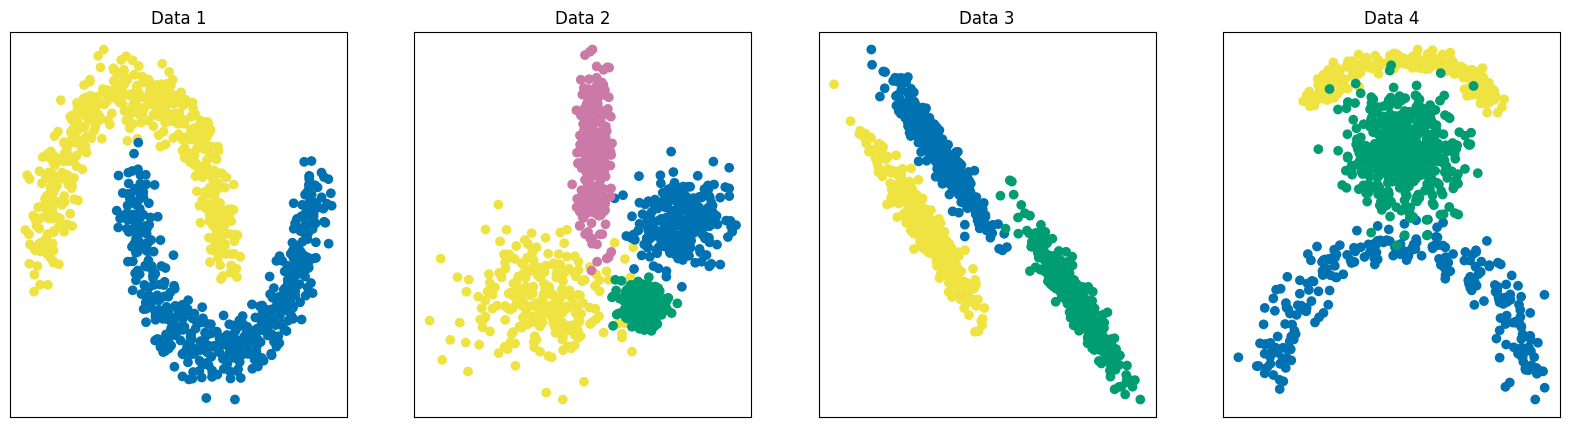

In [5]:
data1 = moons()
data2 = four_gaussians()
data3 = streched_gaussians()
data4 = combined_structure()

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels) in enumerate([data1, data2, data3, data4]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c=[colour['y'] for _ in range(data[labels == 0].shape[0])])
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c=[colour['b'] for _ in range(data[labels == 1].shape[0])])
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c=[colour['g'] for _ in range(data[labels == 2].shape[0])])
    axs[i].scatter(data[labels == 3, 0], data[labels == 3, 1], c=[colour['p'] for _ in range(data[labels == 3].shape[0])])
    axs[i].scatter(data[labels == 4, 0], data[labels == 4, 1], c=[colour['lb'] for _ in range(data[labels == 4].shape[0])])
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()


In [13]:
LAM1 = LAMINAR.LAMINAR(data1[0], drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 1042.750732421875 | Validation Loss: 1586.4853515625
Iteration 99 | Train Loss: 274.8936462402344 | Validation Loss: 270.7677001953125
Iteration 199 | Train Loss: 240.81961059570312 | Validation Loss: 239.33554077148438
Iteration 299 | Train Loss: 223.507080078125 | Validation Loss: 226.03440856933594
Iteration 399 | Train Loss: 216.32664489746094 | Validation Loss: 223.1388702392578
Iteration 499 | Train Loss: 215.28250122070312 | Validation Loss: 222.45880126953125
Iteration 599 | Train Loss: 209.9856719970703 | Validation Loss: 215.34536743164062
Iteration 699 | Train Loss: 209.46585083007812 | Validation Loss: 209.46578979492188
Iteration 799 | Train Loss: 258.3279113769531 | Validation Loss: 255.09437561035156
Iteration 899 | Train Loss: 198.51327514648438 | Validation Loss: 194.30343627929688
Iteration 999 | Train Loss: 189.3878936767578 | Validation Loss: 196.4951934814453
Iteration 1099 | Train Loss: 188.14178466796875 | Validation Loss: 196.3123321533

In [7]:
LAM2 = LAMINAR.LAMINAR(data2[0], drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 1215.7257080078125 | Validation Loss: 1925.3270263671875
Iteration 99 | Train Loss: 259.1329345703125 | Validation Loss: 261.41961669921875
Iteration 199 | Train Loss: 206.47048950195312 | Validation Loss: 205.56430053710938
Iteration 299 | Train Loss: 200.68528747558594 | Validation Loss: 197.7109832763672
Iteration 399 | Train Loss: 196.07366943359375 | Validation Loss: 198.11082458496094
Iteration 499 | Train Loss: 196.9435577392578 | Validation Loss: 198.99786376953125
Iteration 599 | Train Loss: 194.36744689941406 | Validation Loss: 196.3094940185547
Iteration 699 | Train Loss: 192.61741638183594 | Validation Loss: 197.2620849609375
Iteration 799 | Train Loss: 191.99537658691406 | Validation Loss: 197.39877319335938
Iteration 899 | Train Loss: 198.63169860839844 | Validation Loss: 200.03488159179688
Iteration 999 | Train Loss: 190.6454315185547 | Validation Loss: 197.5347442626953
Iteration 1099 | Train Loss: 191.127685546875 | Validation Loss: 198.420516

In [14]:
LAM3 = LAMINAR.LAMINAR(data3[0], drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 1144.469970703125 | Validation Loss: 1855.3231201171875
Iteration 99 | Train Loss: 190.37216186523438 | Validation Loss: 180.32614135742188
Iteration 199 | Train Loss: 166.59478759765625 | Validation Loss: 160.6172637939453
Iteration 299 | Train Loss: 171.1098175048828 | Validation Loss: 164.3489532470703
Iteration 399 | Train Loss: 147.79342651367188 | Validation Loss: 144.39320373535156
Iteration 499 | Train Loss: 145.661376953125 | Validation Loss: 142.586669921875
Iteration 599 | Train Loss: 147.5570526123047 | Validation Loss: 138.42140197753906
Iteration 699 | Train Loss: 140.10020446777344 | Validation Loss: 138.86404418945312
Iteration 799 | Train Loss: 149.874755859375 | Validation Loss: 142.17666625976562
Iteration 899 | Train Loss: 145.0514678955078 | Validation Loss: 135.8852996826172
Iteration 999 | Train Loss: 140.09698486328125 | Validation Loss: 133.35037231445312
Iteration 1099 | Train Loss: 140.1306610107422 | Validation Loss: 135.15040588378

In [9]:
LAM4 = LAMINAR.LAMINAR(data4[0], drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 1234.5860595703125 | Validation Loss: 2103.305908203125
Iteration 99 | Train Loss: 247.21102905273438 | Validation Loss: 264.9873352050781
Iteration 199 | Train Loss: 207.8454132080078 | Validation Loss: 230.58119201660156
Iteration 299 | Train Loss: 192.98983764648438 | Validation Loss: 218.77671813964844
Iteration 399 | Train Loss: 191.22183227539062 | Validation Loss: 219.86727905273438
Iteration 499 | Train Loss: 193.22189331054688 | Validation Loss: 214.2895965576172
Iteration 599 | Train Loss: 189.42823791503906 | Validation Loss: 213.74415588378906
Iteration 699 | Train Loss: 186.98150634765625 | Validation Loss: 211.73509216308594
Iteration 799 | Train Loss: 189.92752075195312 | Validation Loss: 214.63949584960938
Iteration 899 | Train Loss: 184.17144775390625 | Validation Loss: 215.30950927734375
Iteration 999 | Train Loss: 190.5458984375 | Validation Loss: 213.649169921875
Iteration 1099 | Train Loss: 192.77537536621094 | Validation Loss: 219.1266174

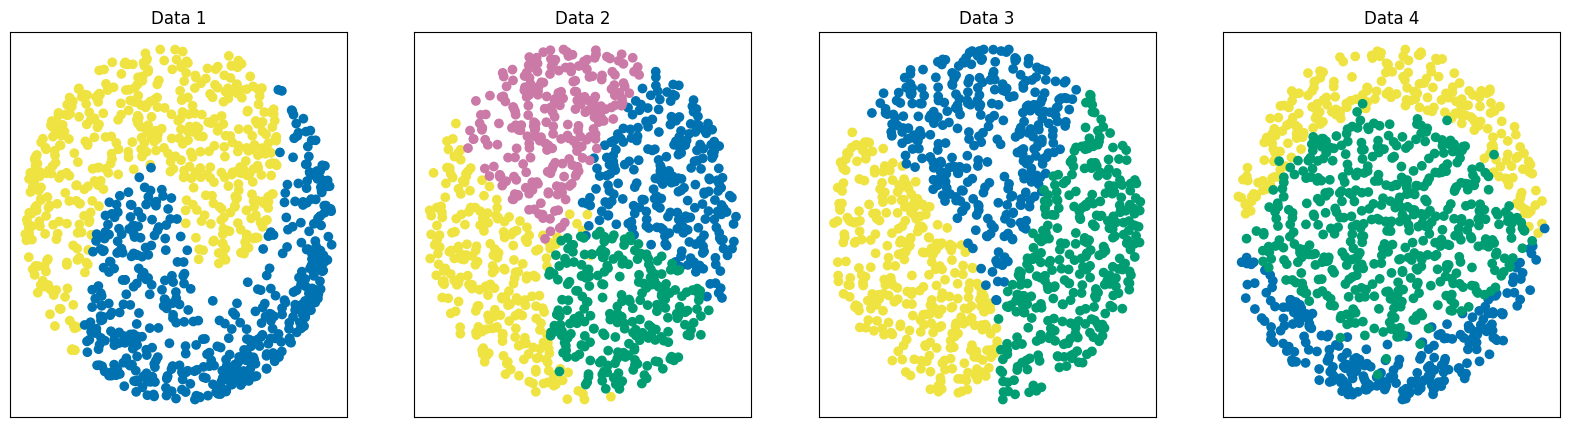

In [17]:
data1_pushed = LAM1.X_pushed
data2_pushed = LAM2.X_pushed
data3_pushed = LAM3.X_pushed
data4_pushed = LAM4.X_pushed

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, data_pushed, data in zip([0, 1, 2, 3], [data1_pushed, data2_pushed, data3_pushed, data4_pushed], [data1, data2, data3, data4]):
    axs[i].scatter(data_pushed[data[1] == 0, 0], data_pushed[data[1] == 0, 1], c=[colour['y'] for _ in range(data_pushed[data[1] == 0].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 1, 0], data_pushed[data[1] == 1, 1], c=[colour['b'] for _ in range(data_pushed[data[1] == 1].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 2, 0], data_pushed[data[1] == 2, 1], c=[colour['g'] for _ in range(data_pushed[data[1] == 2].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 3, 0], data_pushed[data[1] == 3, 1], c=[colour['p'] for _ in range(data_pushed[data[1] == 3].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 4, 0], data_pushed[data[1] == 4, 1], c=[colour['lb'] for _ in range(data_pushed[data[1] == 4].shape[0])])
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

In [36]:
def k_medoids(X, k, max_iter=100):
    """
    K-Medoids clustering algorithm
    :param X: numpy array of shape (n_samples, n_features)
    :param k: Number of clusters
    :param max_iter: Maximum number of iterations
    :return: (medoids, labels)
    """
    n_samples = X.shape[0]
    
    # Randomly initialize k medoids
    medoid_indices = np.random.choice(n_samples, k, replace=False)
    medoids = X[medoid_indices]
    
    for _ in range(max_iter):
        # Compute distance matrix
        distances = pairwise_distances(X, medoids, metric='manhattan')
        
        # Assign labels based on closest medoid
        labels = np.argmin(distances, axis=1)
        
        # Update medoids
        new_medoids = np.copy(medoids)
        for i in range(k):
            cluster_points = X[labels == i]
            if len(cluster_points) == 0:
                continue
            
            # Compute cost for each cluster point as new medoid
            costs = np.sum(pairwise_distances(cluster_points, cluster_points, metric='manhattan'), axis=1)
            new_medoids[i] = cluster_points[np.argmin(costs)]
        
        # Check for convergence
        # Fix: np.all() does not support axis=None for object arrays, use (new_medoids == medoids).all()
        if (new_medoids == medoids).all():
            break
        medoids = new_medoids
    
    return medoids, labels


def k_medoids_LAM(data, k, LAM, max_iter=100):
    # initialize medoids
    medoids = data[torch.randperm(data.size(0))[:k]]
    n = data.shape[0]
    
    for i in range(max_iter):
        # calculate distances
        idx, dists = LAM.query(medoids)
        
        dists = dists[idx < n].reshape(k, n)

        idx, sort_idx = torch.sort(idx, dim=1)
        for _ in range(k):
            dists[_] = dists[_, sort_idx[_]]

        # assign medoids
        _, assignments = dists.min(dim=0)
        new_medoids = torch.clone(medoids)
        # update medoids
        for j in range(k):
            
            # get indices of all points in the cluster j
            cluster_points = idx[j, assignments == j]

            if len(cluster_points) == 0:
                continue

            # get distance matrix of LAM
            distance_matrix, _ = LAMINAR.utils.dijkstra.dijkstra(LAM.graph, cluster_points.cpu().numpy(), cluster_points.cpu().numpy())
            
            distance_matrix = np.array(distance_matrix, dtype=np.float32)

            # only take rows and columns where cluster_points is True
            #distance_matrix = distance_matrix[cluster_points][:, cluster_points]

            distance_matrix = torch.tensor(distance_matrix, dtype=torch.float32)
            # sum over all columns
            sum = torch.sum(distance_matrix, dim=1)

            #print(sum)
            # minimum of the sum is the new medoid centre
            new_medoids[j] = data[cluster_points][sum.argmin()]

            #print('Lowest value in iteration', i, 'is', sum.min(), 'at', new_medoids[j])
            medoids = new_medoids
    return medoids, assignments

In [37]:
# do clustering for all datasets with euclidean metric

medoids1_euc, labels1_euc = k_medoids(data1[0], 2)
medoids2_euc, labels2_euc = k_medoids(data2[0], 4)
medoids3_euc, labels3_euc = k_medoids(data3[0], 3)
medoids4_euc, labels4_euc = k_medoids(data4[0], 3)

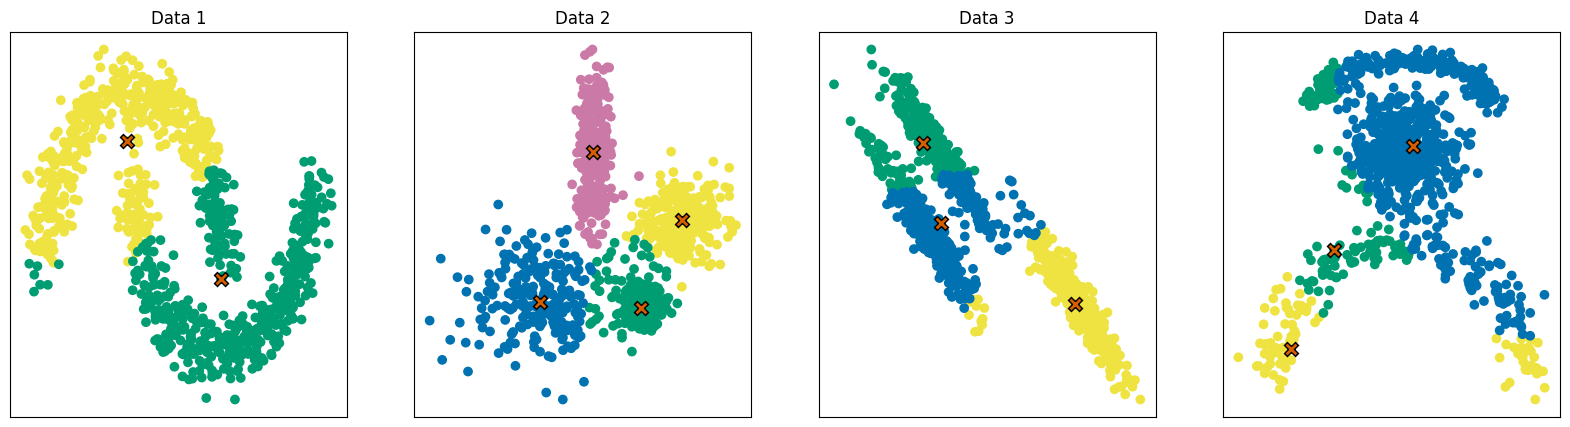

In [38]:
# plot clustering with euclidean
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels, medoids) in enumerate([(data1[0], labels1_euc, medoids1_euc), (data2[0], labels2_euc, medoids2_euc), (data3[0], labels3_euc, medoids3_euc), (data4[0], labels4_euc, medoids4_euc)]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c=[colour['y'] for _ in range(data[labels == 0].shape[0])])
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c=[colour['g'] for _ in range(data[labels == 1].shape[0])])
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c=[colour['b'] for _ in range(data[labels == 2].shape[0])])
    axs[i].scatter(data[labels == 3, 0], data[labels == 3, 1], c=[colour['p'] for _ in range(data[labels == 3].shape[0])])
    axs[i].scatter(data[labels == 4, 0], data[labels == 4, 1], c=[colour['lb'] for _ in range(data[labels == 4].shape[0])])

    axs[i].scatter(medoids[:, 0], medoids[:, 1], c='black', marker='x', s=75, linewidths=4)
    axs[i].scatter(medoids[:, 0], medoids[:, 1], c=[colour['r']], marker='x', s=50, linewidths=2)
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

In [43]:
# same with LAM

medoids1_lam, labels1_lam = k_medoids_LAM(data1[0], 2, LAM1)

In [50]:
medoids2_lam, labels2_lam = k_medoids_LAM(data2[0], 4, LAM2)

In [45]:
medoids3_lam, labels3_lam = k_medoids_LAM(data3[0], 3, LAM3)

In [59]:
medoids4_lam, labels4_lam = k_medoids_LAM(data4[0], 3, LAM4)

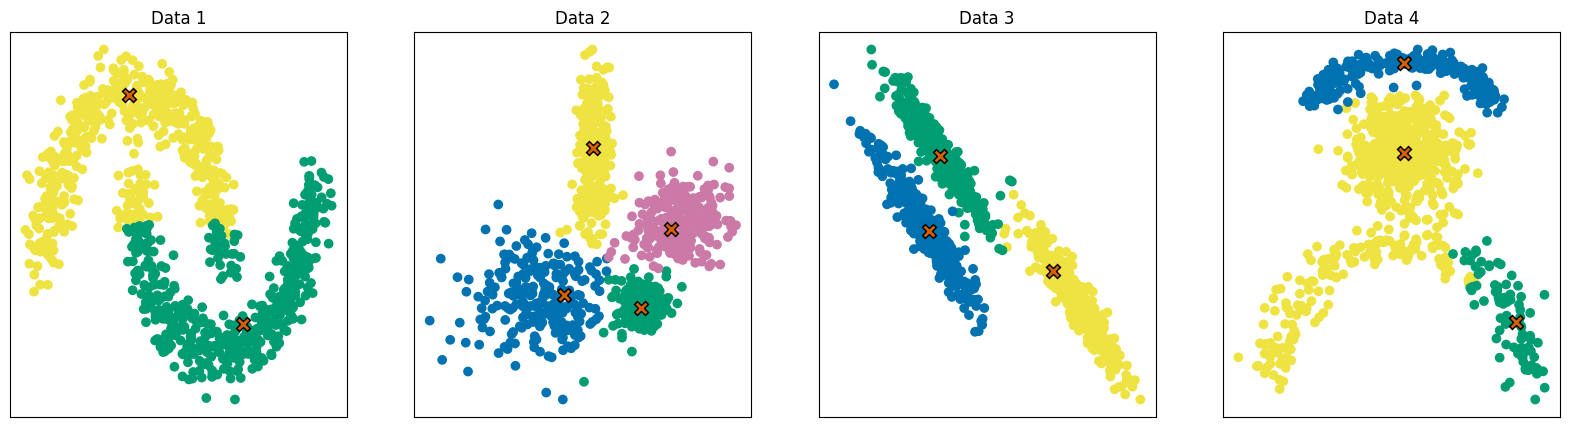

In [60]:
# plot clustering with LAM
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels, medoids) in enumerate([(data1[0], labels1_lam, medoids1_lam), (data2[0], labels2_lam, medoids2_lam), (data3[0], labels3_lam, medoids3_lam), (data4[0], labels4_lam, medoids4_lam)]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c=[colour['y'] for _ in range(data[labels == 0].shape[0])])
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c=[colour['g'] for _ in range(data[labels == 1].shape[0])])
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c=[colour['b'] for _ in range(data[labels == 2].shape[0])])
    axs[i].scatter(data[labels == 3, 0], data[labels == 3, 1], c=[colour['p'] for _ in range(data[labels == 3].shape[0])])
    axs[i].scatter(data[labels == 4, 0], data[labels == 4, 1], c=[colour['lb'] for _ in range(data[labels == 4].shape[0])])

    axs[i].scatter(medoids[:, 0], medoids[:, 1], c='black', marker='x', s=75, linewidths=4)
    axs[i].scatter(medoids[:, 0], medoids[:, 1], c=[colour['r']], marker='x', s=50, linewidths=2)
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

In [61]:
def jaccard(points1, points2):
    n = len(points1)
    m = len(points2)
    intersection = len(set(points1.numpy()).intersection(set(points2.numpy())))

    if m + n - intersection == 0:
        return np.round(0.0, 2)
    else:
        return np.round(intersection / (n + m - intersection), 2)

In [62]:
# calculate jaccard index for all datasets

for i, d, euc_lab, lam_lab in zip([0, 1, 2, 3], [data1, data2, data3, data4], [labels1_euc, labels2_euc, labels3_euc, labels4_euc], [labels1_lam, labels2_lam, labels3_lam, labels4_lam]):
    print('Data ', i+1)
    print('\n')
    
    # get indices of the points with certain labels
    gt_idx_1 = torch.where(d[1] == 0)[0]
    gt_idx_2 = torch.where(d[1] == 1)[0]
    gt_idx_3 = torch.where(d[1] == 2)[0]
    gt_idx_4 = torch.where(d[1] == 3)[0]

    # get indices of the points with certain labels
    euclidean_idx_1 = torch.where(torch.tensor(euc_lab) == 0)[0]
    euclidean_idx_2 = torch.where(torch.tensor(euc_lab) == 1)[0]
    euclidean_idx_3 = torch.where(torch.tensor(euc_lab) == 2)[0]
    euclidean_idx_4 = torch.where(torch.tensor(euc_lab) == 3)[0]

    # sma for lam
    lam_idx_1 = torch.where(lam_lab == 0)[0]
    lam_idx_2 = torch.where(lam_lab == 1)[0]
    lam_idx_3 = torch.where(lam_lab == 2)[0]
    lam_idx_4 = torch.where(lam_lab == 3)[0]

    print('Euclidean')
    print(jaccard(gt_idx_1, euclidean_idx_1), jaccard(gt_idx_2, euclidean_idx_1), jaccard(gt_idx_3, euclidean_idx_1), jaccard(gt_idx_4, euclidean_idx_1))
    print(jaccard(gt_idx_1, euclidean_idx_2), jaccard(gt_idx_2, euclidean_idx_2), jaccard(gt_idx_3, euclidean_idx_2), jaccard(gt_idx_4, euclidean_idx_2))
    print(jaccard(gt_idx_1, euclidean_idx_3), jaccard(gt_idx_2, euclidean_idx_3), jaccard(gt_idx_3, euclidean_idx_3), jaccard(gt_idx_4, euclidean_idx_3))   
    print(jaccard(gt_idx_1, euclidean_idx_4), jaccard(gt_idx_2, euclidean_idx_4), jaccard(gt_idx_3, euclidean_idx_4), jaccard(gt_idx_4, euclidean_idx_4))

    print('\n')

    print('LAM')
    print(jaccard(gt_idx_1, lam_idx_1), jaccard(gt_idx_2, lam_idx_1), jaccard(gt_idx_3, lam_idx_1), jaccard(gt_idx_4, lam_idx_1))
    print(jaccard(gt_idx_1, lam_idx_2), jaccard(gt_idx_2, lam_idx_2), jaccard(gt_idx_3, lam_idx_2), jaccard(gt_idx_4, lam_idx_2))
    print(jaccard(gt_idx_1, lam_idx_3), jaccard(gt_idx_2, lam_idx_3), jaccard(gt_idx_3, lam_idx_3), jaccard(gt_idx_4, lam_idx_3))
    print(jaccard(gt_idx_1, lam_idx_4), jaccard(gt_idx_2, lam_idx_4), jaccard(gt_idx_3, lam_idx_4), jaccard(gt_idx_4, lam_idx_4))

    print('\n')



    

Data  1


Euclidean
0.72 0.07 0.0 0.0
0.1 0.73 0.0 0.0
0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0


LAM
0.86 0.05 0.0 0.0
0.04 0.85 0.0 0.0
0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0


Data  2


Euclidean
0.0 0.94 0.0 0.0
0.04 0.02 0.87 0.01
0.9 0.0 0.0 0.0
0.0 0.01 0.0 0.97


LAM
0.0 0.0 0.0 0.96
0.02 0.01 0.94 0.0
0.93 0.0 0.0 0.01
0.01 0.95 0.0 0.0


Data  3


Euclidean
0.02 0.0 0.92 0.0
0.11 0.58 0.0 0.0
0.57 0.17 0.02 0.0
0.0 0.0 0.0 0.0


LAM
0.0 0.0 0.99 0.0
0.0 0.98 0.0 0.0
1.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0


Data  4


Euclidean
0.0 0.35 0.0 0.0
0.16 0.22 0.03 0.0
0.24 0.1 0.61 0.0
0.0 0.0 0.0 0.0


LAM
0.0 0.22 0.74 0.0
0.0 0.35 0.0 0.0
0.96 0.0 0.01 0.0
0.0 0.0 0.0 0.0


